# Stage 14 — Prototype Quality Metrics

Runs all six prototype quality metrics on a trained checkpoint and saves outputs to `results/v4/proto_quality/{run_name}/`.

All computation logic lives in `src/metrics/proto_quality.py`. This notebook handles config, execution, and saving only.

**Metrics computed:**
1. Purity — are top activations on the correct class?
2. Utilization — which prototypes are alive?
3. Compactness — how spatially focused are activations?
4. Dice Sensitivity — which prototypes are causally important?
5. Level Dominance — which scale level wins the max aggregation?
6. Per-level AP — which level produces the most precise heatmaps?

## 0. Config

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from src.models.proto_seg_net import ProtoSegNet
from src.data.mmwhs_dataset import MMWHSSliceDataset
from torch.utils.data import DataLoader
import src.metrics.proto_quality as pq

# ── User config ───────────────────────────────────────────────────────────────
CHECKPOINT   = "../checkpoints/proto_seg_ct_l2.pth"
DATA_DIR     = "../data/pack/processed_data"
MODALITY     = "ct"
RUN_NAME     = "v1"          # subfolder under results/v4/proto_quality/
TOP_N_PURITY = 50
BATCH_SIZE   = 16

OUT_DIR = Path(f"../results/v4/proto_quality/{RUN_NAME}")
OUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = (
    torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cuda") if torch.cuda.is_available()
    else torch.device("cpu")
)
print(f"Device: {DEVICE}")
print(f"Output dir: {OUT_DIR.resolve()}")

Device: mps
Output dir: /Users/amo/programData/cardiac-proto-segmentation/results/v4/proto_quality/v1


## 1. Load Model & Data

In [2]:
# ── Load checkpoint ───────────────────────────────────────────────────────────
ckpt = torch.load(CHECKPOINT, map_location="cpu")

model_kwargs = {
    "single_scale": ckpt.get("single_scale", False),
    "hard_mask":    ckpt.get("hard_mask", False),
    "no_soft_mask": ckpt.get("no_soft_mask", False),
}
model = ProtoSegNet(**model_kwargs)
model.load_state_dict(ckpt["model_state_dict"])
model = model.to(DEVICE)
model.eval()

active_levels = sorted(model.proto_layers_dict().keys())
print(f"Active prototype levels: {active_levels}")
for l, pl in model.proto_layers_dict().items():
    print(f"  Level {l}: {pl.n_classes} classes × {pl.n_protos} protos × {pl.feature_dim} dims")

Active prototype levels: [1, 2, 3, 4]
  Level 1: 8 classes × 4 protos × 32 dims
  Level 2: 8 classes × 3 protos × 64 dims
  Level 3: 8 classes × 2 protos × 128 dims
  Level 4: 8 classes × 2 protos × 256 dims


In [3]:
# ── Dataloaders ───────────────────────────────────────────────────────────────
train_ds = MMWHSSliceDataset(DATA_DIR, modality=MODALITY, split="train", preload=True)
test_ds  = MMWHSSliceDataset(DATA_DIR, modality=MODALITY, split="test",  preload=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train slices: {len(train_ds)}  |  Test slices: {len(test_ds)}")

Train slices: 3389  |  Test slices: 484


## 2. Purity  (train set)
Fraction of top-N activations where GT label == prototype class.

In [4]:
print("Computing purity (train set) — this may take a few minutes...")
df_purity = pq.compute_purity(model, train_loader, top_n=TOP_N_PURITY)
df_purity.to_csv(OUT_DIR / "purity_per_prototype.csv", index=False)

# Summary: mean purity per level
df_purity_summary = (
    df_purity.groupby("level")["purity"].agg(["mean", "min", "max"])
    .round(3).reset_index()
)
df_purity_summary.to_csv(OUT_DIR / "purity_summary.csv", index=False)

print("\nPurity by level:")
display(df_purity_summary)

print("\nPurity by class (mean over levels):")
display(df_purity.groupby("class_name")["purity"].mean().round(3).to_frame())

Computing purity (train set) — this may take a few minutes...



Purity by level:


,level,mean,min,max
0,1,0.050,0.00,0.28
1,2,0.184,0.00,0.66
2,3,0.639,0.08,1.00
3,4,0.824,0.40,1.00



Purity by class (mean over levels):


,purity
class_name,
Aorta,0.356
LA,0.407
LV,0.298
Myo,0.344
PA,0.220
RA,0.342
RV,0.373


## 3. Utilization  (test set)
Which prototypes are alive (max activation > 0.1)?

In [5]:
print("Computing utilization (test set)...")
df_util = pq.compute_utilization(model, test_loader, threshold=0.1)
df_util.to_csv(OUT_DIR / "utilization.csv", index=False)

total_protos = len(df_util)
dead_protos  = df_util["is_dead"].sum()
print(f"\nDead prototypes: {dead_protos} / {total_protos}  ({100*dead_protos/total_protos:.1f}%)")

if dead_protos > 0:
    print("\nDead prototype details:")
    display(df_util[df_util["is_dead"]])

Computing utilization (test set)...



Dead prototypes: 0 / 77  (0.0%)


## 4. Compactness  (test set)
Fraction of 256×256 image with activation > 0.5. Lower = more focused.

In [6]:
print("Computing compactness (test set)...")
df_compact = pq.compute_compactness(model, test_loader, act_threshold=0.5)
df_compact.to_csv(OUT_DIR / "compactness.csv", index=False)

print("\nCompactness by level (mean):")
display(
    df_compact.groupby("level")[["compactness", "level_threshold"]]
    .agg({"compactness": "mean", "level_threshold": "first"})
    .round(4)
)

Computing compactness (test set)...



Compactness by level (mean):


,compactness,level_threshold
level,,
1,0.3402,0.05
2,0.4176,0.08
3,0.5416,0.15
4,0.5732,0.25


## 5. Dice Sensitivity  (test set)
Dice drop when each prototype is ablated. Slow — runs 88 ablated forward passes over the test set.

In [7]:
print("Computing Dice sensitivity (test set) — takes ~2 min...")
df_sens = pq.compute_dice_sensitivity(model, test_loader)
df_sens.to_csv(OUT_DIR / "dice_sensitivity.csv", index=False)

important_threshold = 0.005
n_important = (df_sens["dice_drop"] > important_threshold).sum()
print(f"\nPrototypes with Dice drop > {important_threshold}: {n_important} / {len(df_sens)}")
print("\nTop-10 most important prototypes:")
display(df_sens.head(10)[["level", "class_name", "proto_idx", "baseline_dice", "ablated_dice", "dice_drop"]])

Computing Dice sensitivity (test set) — takes ~2 min...



Prototypes with Dice drop > 0.005: 7 / 77

Top-10 most important prototypes:


,level,class_name,proto_idx,baseline_dice,ablated_dice,dice_drop
0,3,RV,0,0.705001,0.697069,0.007932
1,3,PA,1,0.705001,0.697077,0.007924
2,3,Aorta,0,0.705001,0.697093,0.007908
3,3,LV,0,0.705001,0.697094,0.007907
4,3,RA,0,0.705001,0.697123,0.007877
5,3,Myo,0,0.705001,0.697125,0.007876
6,3,LA,1,0.705001,0.697148,0.007853
7,4,Aorta,0,0.705001,0.700389,0.004612
8,4,RA,0,0.705001,0.700421,0.004580
9,4,RV,0,0.705001,0.700449,0.004552


## 6. Level Dominance  (test set)
Which level wins the cross-level max aggregation per pixel?

Computing level dominance (test set)...


,frac_l1,frac_l2,frac_l3,frac_l4
0,0.3425,0.4423,0.1721,0.0431


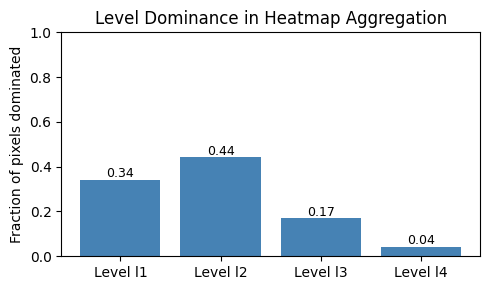

In [8]:
print("Computing level dominance (test set)...")
df_dom = pq.compute_level_dominance(model, test_loader)
df_dom.to_csv(OUT_DIR / "level_dominance.csv", index=False)

display(df_dom.round(4))

# Bar chart
cols = [c for c in df_dom.columns if c.startswith("frac_")]
vals = df_dom[cols].values[0]
labels_dom = [c.replace("frac_", "Level ") for c in cols]

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(labels_dom, vals, color="steelblue")
ax.set_ylabel("Fraction of pixels dominated")
ax.set_title("Level Dominance in Heatmap Aggregation")
ax.set_ylim(0, 1)
for i, v in enumerate(vals):
    ax.text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)
plt.tight_layout()
fig.savefig(OUT_DIR / "level_dominance.png", dpi=150)
plt.show()

## 7. Per-level AP  (test set)
AP computed using each level's heatmap in isolation.

In [9]:
print("Computing per-level AP (test set)...")
df_ap = pq.compute_per_level_ap(model, test_loader)
df_ap.to_csv(OUT_DIR / "per_level_ap.csv", index=False)

print("\nMean AP by level:")
display(df_ap.groupby("level")["ap"].mean().round(4).to_frame())

# Pivot for heatmap
pivot = df_ap.pivot(index="class_name", columns="level", values="ap").round(3)
print("\nPer-class per-level AP:")
display(pivot)

Computing per-level AP (test set)...



Mean AP by level:


,ap
level,
1,0.0432
2,0.1117
3,0.0683
4,0.1892



Per-class per-level AP:


level,1,2,3,4
class_name,,,,
Aorta,0.030,0.036,0.040,0.297
LA,0.027,0.068,0.116,0.190
LV,0.049,0.052,0.070,0.198
Myo,0.050,0.207,0.102,0.115
PA,0.023,0.084,0.020,0.106
RA,0.072,0.110,0.087,0.187
RV,0.051,0.224,0.044,0.232


## 8. Prototype Atlas  (train set)
Nearest training patch per prototype for each level.

Building atlas for level 1...


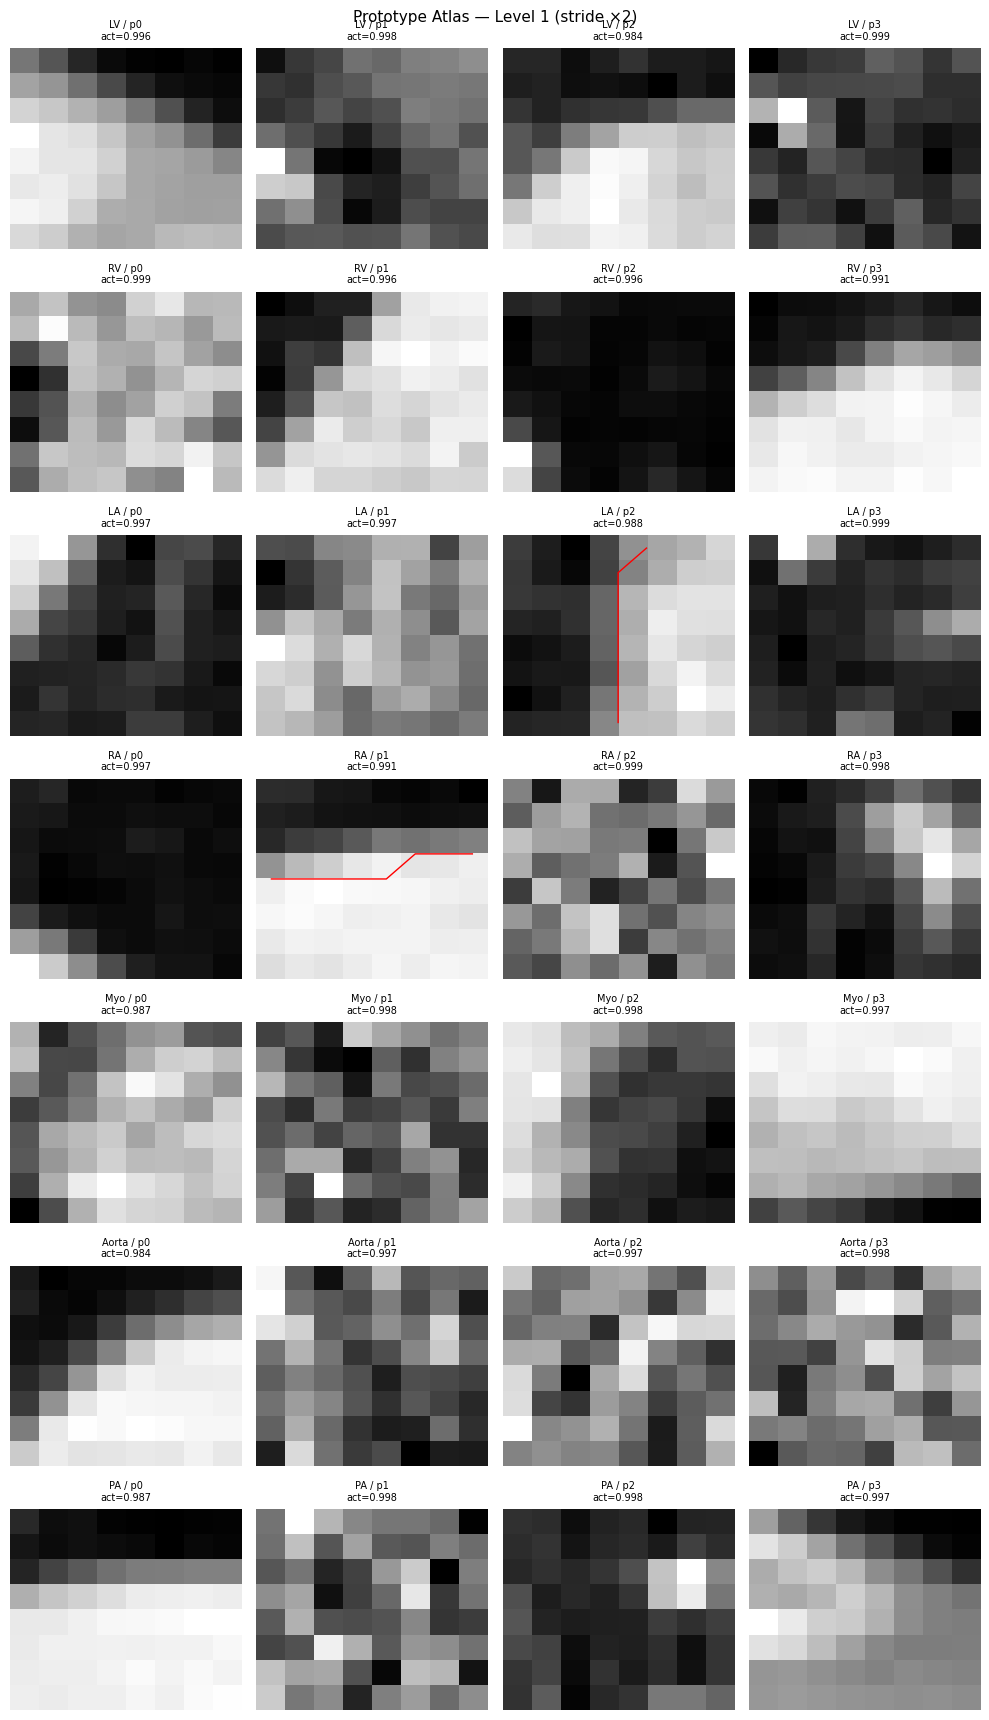

  Saved → ../results/v4/proto_quality/v1/prototype_atlas_level1.png
Building atlas for level 2...


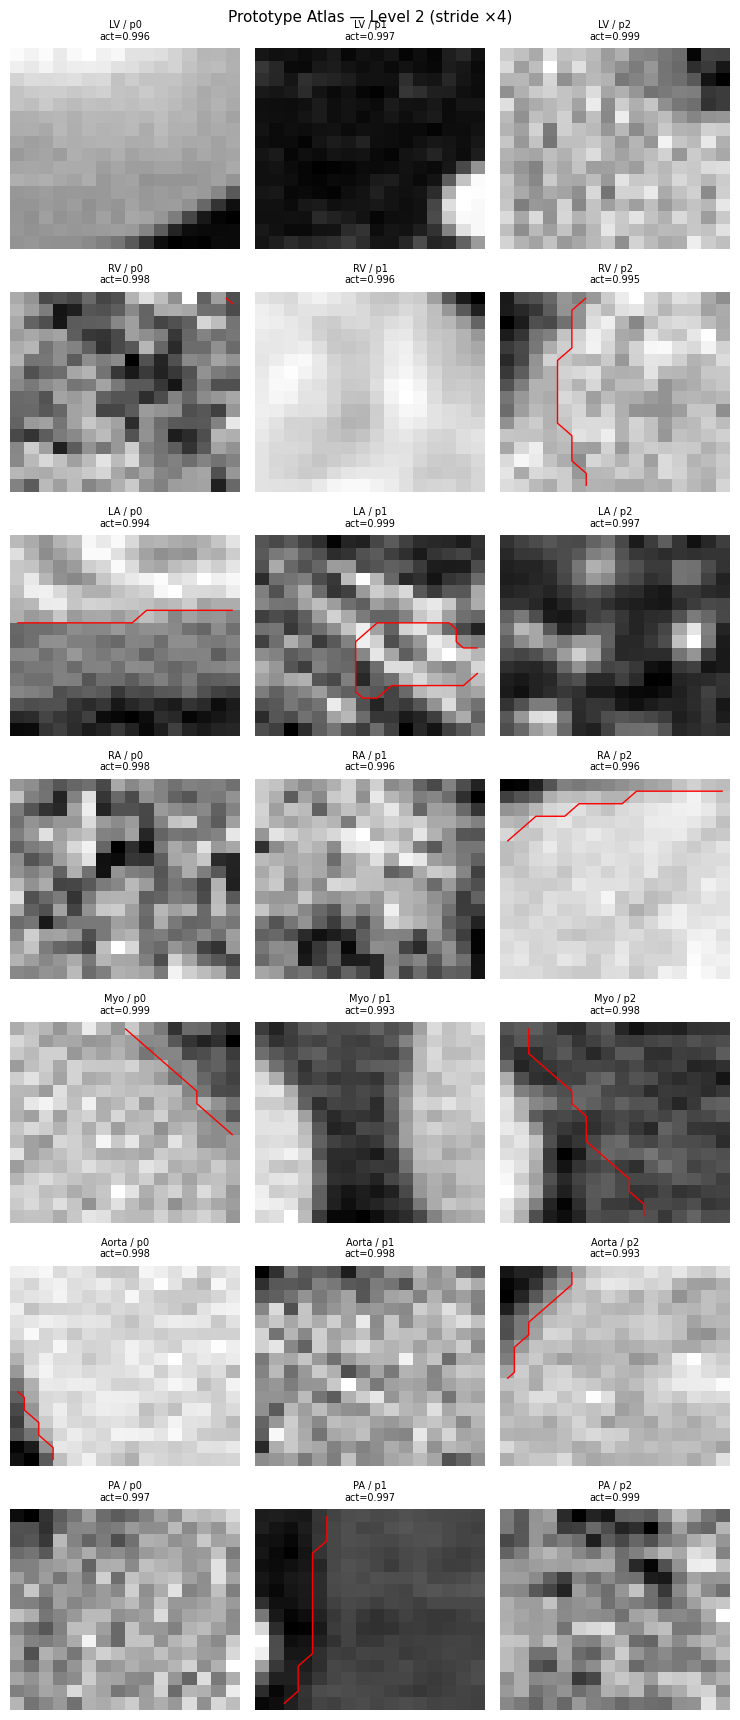

  Saved → ../results/v4/proto_quality/v1/prototype_atlas_level2.png
Building atlas for level 3...


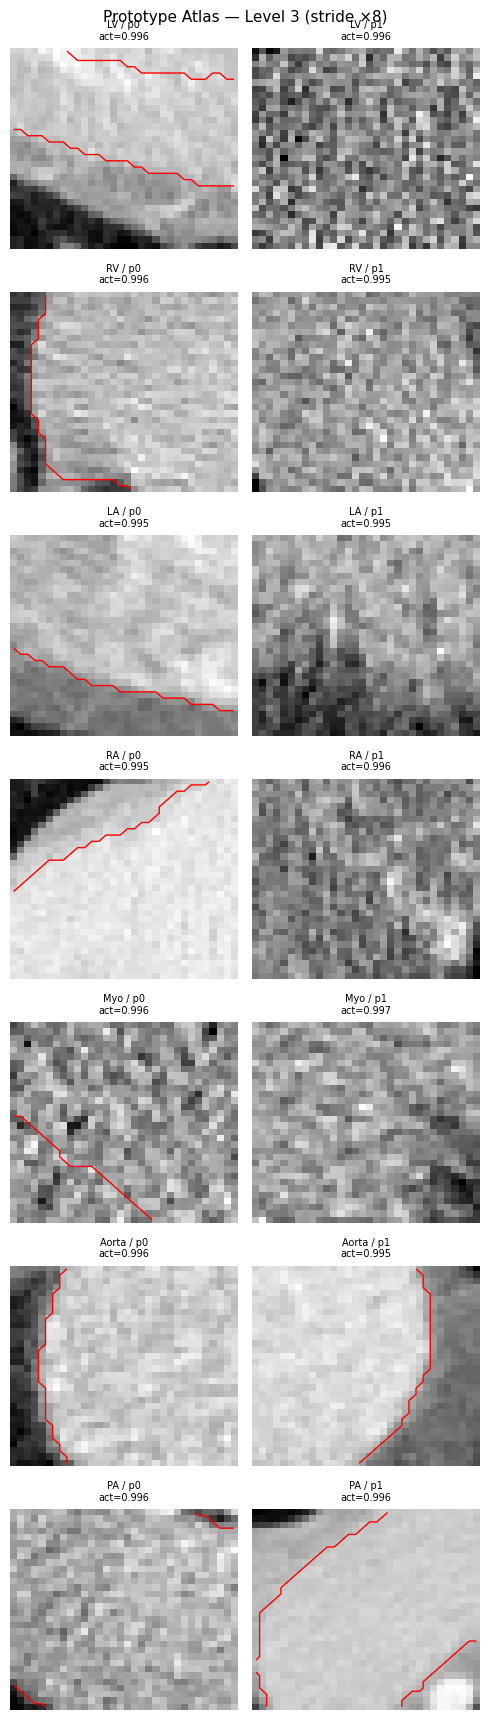

  Saved → ../results/v4/proto_quality/v1/prototype_atlas_level3.png
Building atlas for level 4...


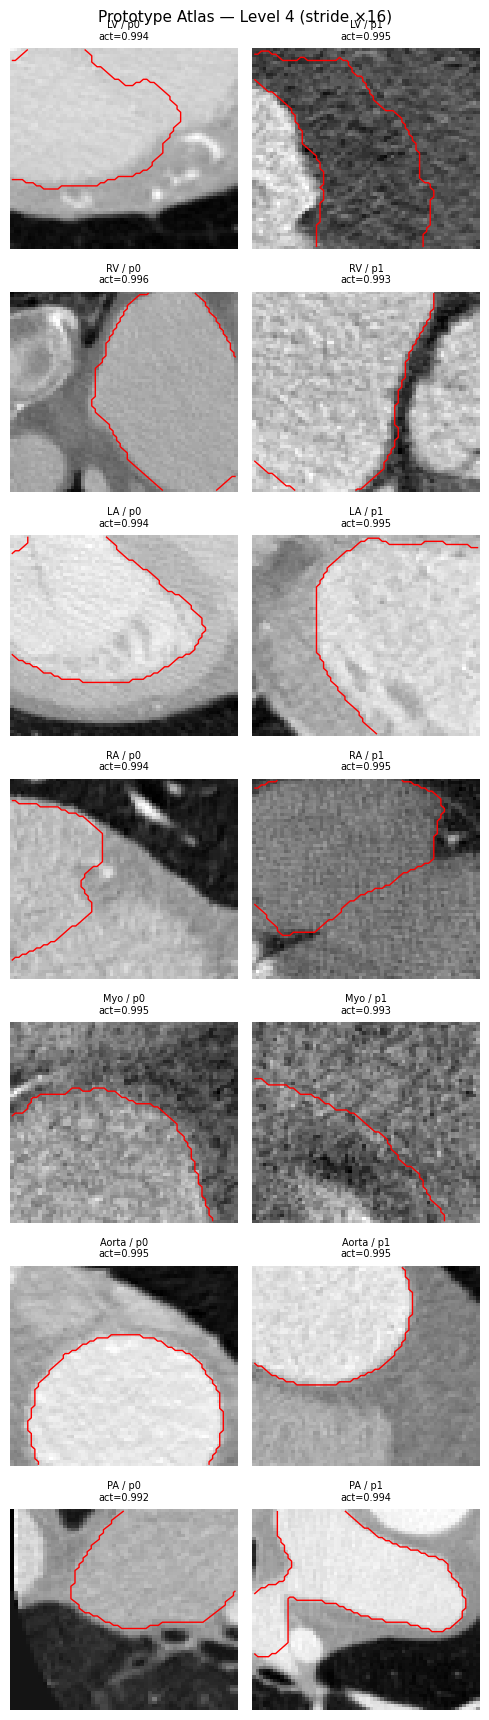

  Saved → ../results/v4/proto_quality/v1/prototype_atlas_level4.png


In [10]:
for level in active_levels:
    print(f"Building atlas for level {level}...")
    fig = pq.build_prototype_atlas(model, train_loader, level=level)
    out_path = OUT_DIR / f"prototype_atlas_level{level}.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved → {out_path}")

## 9. Smoke Test Summary

In [11]:
print("=" * 50)
print("SMOKE TEST SUMMARY")
print("=" * 50)

checks = [
    ("purity_per_prototype.csv",  df_purity),
    ("utilization.csv",           df_util),
    ("compactness.csv",           df_compact),
    ("dice_sensitivity.csv",      df_sens),
    ("level_dominance.csv",       df_dom),
    ("per_level_ap.csv",          df_ap),
]

all_ok = True
for fname, df in checks:
    has_nan  = df.select_dtypes(include="number").isna().any().any()
    n_rows   = len(df)
    status   = "✅" if not has_nan else "⚠️  NaN values present"
    print(f"  {fname:<40} {n_rows:>4} rows  {status}")
    if has_nan:
        all_ok = False

print()
print(f"Output directory: {OUT_DIR.resolve()}")
saved = list(OUT_DIR.glob("*"))
print(f"Files saved: {len(saved)}")
for f in sorted(saved):
    print(f"  {f.name}")

print()
print("✅ All outputs clean." if all_ok else "⚠️  Check NaN values above.")

SMOKE TEST SUMMARY
  purity_per_prototype.csv                   77 rows  ✅
  utilization.csv                            77 rows  ✅
  compactness.csv                            77 rows  ✅
  dice_sensitivity.csv                       77 rows  ✅
  level_dominance.csv                         1 rows  ✅
  per_level_ap.csv                           28 rows  ✅

Output directory: /Users/amo/programData/cardiac-proto-segmentation/results/v4/proto_quality/v1
Files saved: 12
  compactness.csv
  dice_sensitivity.csv
  level_dominance.csv
  level_dominance.png
  per_level_ap.csv
  prototype_atlas_level1.png
  prototype_atlas_level2.png
  prototype_atlas_level3.png
  prototype_atlas_level4.png
  purity_per_prototype.csv
  purity_summary.csv
  utilization.csv

✅ All outputs clean.
